# Document Extraction on Low-Cost Cloud GPUs: Speed, Quality and Cost

We ran an open-source language model on rented cloud GPUs to pull structured information out of five kinds of business documents. We varied the hardware and the batch size across four runs and measured speed, accuracy and cost.

**Data:** every result uses the public Hugging Face dataset `Lucius-Morningstar/mailroom-dataset`. No American Family Insurance data was used or shared.

## Key findings

1. **Adding a second GPU doubles speed at the same cost per document.** On the same 250 documents, moving from 1 GPU to 2 GPUs processed 99% more documents per minute, and GPU cost per document changed by only +0.4%. The trade-off: each document waited 1.4–1.8 times longer for its answer, because more documents shared the GPUs at once. This setup suits batch processing; latency-sensitive use would need different tuning.
2. **Larger batches are cheaper.** On the 2-GPU setup, processing 100 documents of each type instead of 50 cut GPU cost per document by 19% (four document types; merger agreements excluded because their settings changed). 1 of 400 documents failed.
3. **Hardware choice did not change accuracy.** Comparing the same documents across runs (420 document pairs), the average score change per document type was between -0.017 and +0.023 on a 0–1 scale, and every 95% confidence interval includes zero. Effects smaller than about ±0.04 cannot be ruled out at this sample size.
4. **Merger agreements are the weak spot; reading the whole agreement helps.** These contracts are far longer than the model can read in one pass. Splitting each agreement into overlapping sections and combining the answers raised accuracy from 3.5% to 14.0% and the share of questions answered from 23% to 69%, at 4.5 times the cost per agreement.
5. **The full study cost $3.39 in cloud charges for 1,050 documents** (about 0.32 cents each, all-in), and $0.00 was billed after the provider's free credits.

## What we tested

**The task.** An automated mailroom reads each incoming document and returns its key facts as structured data (for example parties, dates, amounts, and which contract clauses are present). Each of the five document types has its own extraction instructions:

| Document type | What it contains | How accuracy is measured |
| --- | --- | --- |
| Insurance Claims | Insurance claim forms and notices | Extraction score |
| Contracts | Commercial contracts | Clause F1 (CUAD) |
| Corporate Records | Corporate filings and records | Extraction score |
| Correspondence | Business letters and email | Extraction score |
| Merger Agreements | Merger agreements (often 100+ pages) | Question accuracy (MAUD) |

**The model.** Qwen/Qwen3-8B-AWQ: an open-weights model with 8 billion parameters, compressed to 4-bit weights (AWQ) so it fits on a single 24 GB GPU. It ran on vLLM, an open-source model server, on NVIDIA L4 GPUs rented from Modal at $0.80 per GPU-hour.

**The sample.** Documents were drawn at random with a fixed seed (42), so every run is reproducible. Smaller samples are subsets of larger ones, so runs can be compared on the same documents.

## The four runs

| Run | GPUs | Documents processed at once | Documents per type | Total documents |
| --- | ---: | ---: | ---: | ---: |
| Run A | 1 | 8 | 20 | 100 |
| Run B | 1 | 8 | 50 | 250 |
| Run C | 2 | 32 | 50 | 250 |
| Run D | 2 | 32 | 100 (merger agreements: 50) | 450 |

Runs B and C use the identical 250 documents and differ only in GPU count and documents processed at once, so they give the cleanest hardware comparison. Run D repeats Run C's hardware on twice as many documents and also tests improved settings for merger agreements (described below).

## How to read the numbers

| Term | Meaning |
| --- | --- |
| Token | The unit a language model reads and writes; roughly three-quarters of an English word. |
| Documents per minute | Overall throughput for the run: documents finished ÷ total run time. |
| Tokens per second per GPU | Text processed (read plus written) per second by each GPU; a hardware-efficiency measure. |
| Median time per document | Half of documents finished faster than this, half slower (seconds from submission to answer). |
| GPU cost per document | GPU time the documents actually used × $0.80/hour ÷ documents. Excludes start-up and idle time. |
| Session cost | What the cloud provider metered for the whole session, including start-up, waiting and shut-down. |
| Failed document | The model's answer exceeded the output length limit (8,192 tokens) and was cut off, so no result was returned. |
| Extraction score | 0–1. Average agreement between extracted fields and the dataset's answer key, per document. |
| Clause F1 (CUAD) | 0–1. CUAD is a public set of commercial contracts with lawyer-labeled clause types. F1 balances finding the clauses that are present against flagging clauses that are not. |
| Question accuracy (MAUD) | 0–1. MAUD is a public set of merger agreements with lawyer-written multiple-choice questions. Accuracy is the share of all labeled questions answered correctly; coverage is the share the model answered at all. |
| 95% confidence interval | The range that likely contains the true difference; if it includes zero, the data show no reliable difference. |

The three scores use different scales, so compare them across runs, not across document types.

## Speed and cost by run

| Measure | Run A | Run B | Run C | Run D |
| --- | ---: | ---: | ---: | ---: |
| Documents per minute | 8.7 | 10.4 | 20.7 | 11.9 |
| Tokens per second per GPU | 812 | 1,002 | 1,013 | 1,662 |
| GPU cost per document | $0.00153 | $0.00128 | $0.00129 | $0.00225 |
| Failed documents | 3 of 100 | 7 of 250 | 5 of 250 | 1 of 450 |

Every failure was an answer cut off at the output length limit, all on contracts or merger agreements (the longest documents).

Run D's cost and throughput include the slower, more thorough merger-agreement settings; the like-for-like batch-size comparison is in Key finding 2.

The charts below are drawn from this data table (re-run the cells to edit them).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

COLORS = {"Run A": "#2a78d6", "Run B": "#eb6834", "Run C": "#1baf7a", "Run D": "#eda100"}
df = pd.DataFrame([
 {
  "run": "Run A",
  "doc_type": "Insurance Claims",
  "score": 0.6836,
  "cost_per_doc": 0.00042,
  "median_seconds": 13.2,
  "run_docs_per_min": 8.74,
  "run_cost_per_doc": 0.001526
 },
 {
  "run": "Run A",
  "doc_type": "Contracts",
  "score": 0.5974,
  "cost_per_doc": 0.003501,
  "median_seconds": 65.8,
  "run_docs_per_min": 8.74,
  "run_cost_per_doc": 0.001526
 },
 {
  "run": "Run A",
  "doc_type": "Corporate Records",
  "score": 0.4592,
  "cost_per_doc": 0.00026,
  "median_seconds": 14.4,
  "run_docs_per_min": 8.74,
  "run_cost_per_doc": 0.001526
 },
 {
  "run": "Run A",
  "doc_type": "Correspondence",
  "score": 0.3268,
  "cost_per_doc": 0.000112,
  "median_seconds": 5.8,
  "run_docs_per_min": 8.74,
  "run_cost_per_doc": 0.001526
 },
 {
  "run": "Run A",
  "doc_type": "Merger Agreements",
  "score": 0.0138,
  "cost_per_doc": 0.003903,
  "median_seconds": 50.5,
  "run_docs_per_min": 8.74,
  "run_cost_per_doc": 0.001526
 },
 {
  "run": "Run B",
  "doc_type": "Insurance Claims",
  "score": 0.6838,
  "cost_per_doc": 0.000389,
  "median_seconds": 14.0,
  "run_docs_per_min": 10.4,
  "run_cost_per_doc": 0.001282
 },
 {
  "run": "Run B",
  "doc_type": "Contracts",
  "score": 0.5897,
  "cost_per_doc": 0.003098,
  "median_seconds": 68.2,
  "run_docs_per_min": 10.4,
  "run_cost_per_doc": 0.001282
 },
 {
  "run": "Run B",
  "doc_type": "Corporate Records",
  "score": 0.4492,
  "cost_per_doc": 0.000316,
  "median_seconds": 13.2,
  "run_docs_per_min": 10.4,
  "run_cost_per_doc": 0.001282
 },
 {
  "run": "Run B",
  "doc_type": "Correspondence",
  "score": 0.3446,
  "cost_per_doc": 0.00018,
  "median_seconds": 6.6,
  "run_docs_per_min": 10.4,
  "run_cost_per_doc": 0.001282
 },
 {
  "run": "Run B",
  "doc_type": "Merger Agreements",
  "score": 0.0479,
  "cost_per_doc": 0.002843,
  "median_seconds": 51.3,
  "run_docs_per_min": 10.4,
  "run_cost_per_doc": 0.001282
 },
 {
  "run": "Run C",
  "doc_type": "Insurance Claims",
  "score": 0.6859,
  "cost_per_doc": 0.000316,
  "median_seconds": 19.6,
  "run_docs_per_min": 20.71,
  "run_cost_per_doc": 0.001288
 },
 {
  "run": "Run C",
  "doc_type": "Contracts",
  "score": 0.6051,
  "cost_per_doc": 0.002837,
  "median_seconds": 103.3,
  "run_docs_per_min": 20.71,
  "run_cost_per_doc": 0.001288
 },
 {
  "run": "Run C",
  "doc_type": "Corporate Records",
  "score": 0.452,
  "cost_per_doc": 0.000188,
  "median_seconds": 24.1,
  "run_docs_per_min": 20.71,
  "run_cost_per_doc": 0.001288
 },
 {
  "run": "Run C",
  "doc_type": "Correspondence",
  "score": 0.334,
  "cost_per_doc": 0.000124,
  "median_seconds": 10.7,
  "run_docs_per_min": 20.71,
  "run_cost_per_doc": 0.001288
 },
 {
  "run": "Run C",
  "doc_type": "Merger Agreements",
  "score": 0.0348,
  "cost_per_doc": 0.003293,
  "median_seconds": 92.5,
  "run_docs_per_min": 20.71,
  "run_cost_per_doc": 0.001288
 },
 {
  "run": "Run D",
  "doc_type": "Insurance Claims",
  "score": 0.6715,
  "cost_per_doc": 0.000362,
  "median_seconds": 20.4,
  "run_docs_per_min": 11.86,
  "run_cost_per_doc": 0.002248
 },
 {
  "run": "Run D",
  "doc_type": "Contracts",
  "score": 0.6082,
  "cost_per_doc": 0.002068,
  "median_seconds": 96.1,
  "run_docs_per_min": 11.86,
  "run_cost_per_doc": 0.002248
 },
 {
  "run": "Run D",
  "doc_type": "Corporate Records",
  "score": 0.4755,
  "cost_per_doc": 0.000214,
  "median_seconds": 19.9,
  "run_docs_per_min": 11.86,
  "run_cost_per_doc": 0.002248
 },
 {
  "run": "Run D",
  "doc_type": "Correspondence",
  "score": 0.3413,
  "cost_per_doc": 0.000122,
  "median_seconds": 10.3,
  "run_docs_per_min": 11.86,
  "run_cost_per_doc": 0.002248
 },
 {
  "run": "Run D",
  "doc_type": "Merger Agreements",
  "score": 0.1395,
  "cost_per_doc": 0.014745,
  "median_seconds": 1044.4,
  "run_docs_per_min": 11.86,
  "run_cost_per_doc": 0.002248
 }
])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
df.head()

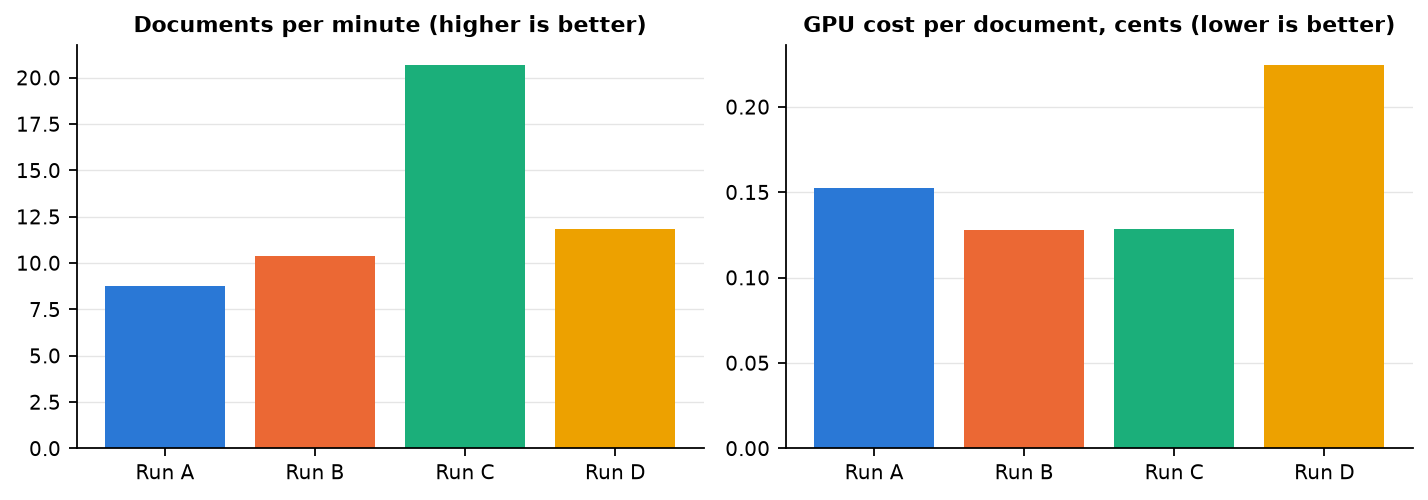

In [ ]:
runs = df.drop_duplicates("run").set_index("run")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].bar(runs.index, runs["run_docs_per_min"], color=[COLORS[r] for r in runs.index])
axes[0].set_title("Documents per minute (higher is better)")
axes[1].bar(runs.index, runs["run_cost_per_doc"] * 100, color=[COLORS[r] for r in runs.index])
axes[1].set_title("GPU cost per document, cents (lower is better)")
fig.tight_layout()

## Results by document type

Scores by document type (0–1, higher is better):

| Document type | Measure | Run A | Run B | Run C | Run D |
| --- | --- | ---: | ---: | ---: | ---: |
| Insurance Claims | Extraction score | 0.684 | 0.684 | 0.686 | 0.672 |
| Contracts | Clause F1 (CUAD) | 0.597 | 0.590 | 0.605 | 0.608 |
| Corporate Records | Extraction score | 0.459 | 0.449 | 0.452 | 0.475 |
| Correspondence | Extraction score | 0.327 | 0.345 | 0.334 | 0.341 |
| Merger Agreements | Question accuracy (MAUD) | 0.014 | 0.048 | 0.035 | 0.140* |

\* Run D uses the improved merger-agreement settings.

Cost per successfully processed document (US dollars):

| Document type | Run A | Run B | Run C | Run D |
| --- | ---: | ---: | ---: | ---: |
| Insurance Claims | $0.00042 | $0.00039 | $0.00032 | $0.00036 |
| Contracts | $0.00350 | $0.00310 | $0.00284 | $0.00207 |
| Corporate Records | $0.00026 | $0.00032 | $0.00019 | $0.00021 |
| Correspondence | $0.00011 | $0.00018 | $0.00012 | $0.00012 |
| Merger Agreements | $0.00390 | $0.00284 | $0.00329 | $0.01475 |

Median seconds per document:

| Document type | Run A | Run B | Run C | Run D |
| --- | ---: | ---: | ---: | ---: |
| Insurance Claims | 13 | 14 | 20 | 20 |
| Contracts | 66 | 68 | 103 | 96 |
| Corporate Records | 14 | 13 | 24 | 20 |
| Correspondence | 6 | 7 | 11 | 10 |
| Merger Agreements | 50 | 51 | 92 | 1,044 |

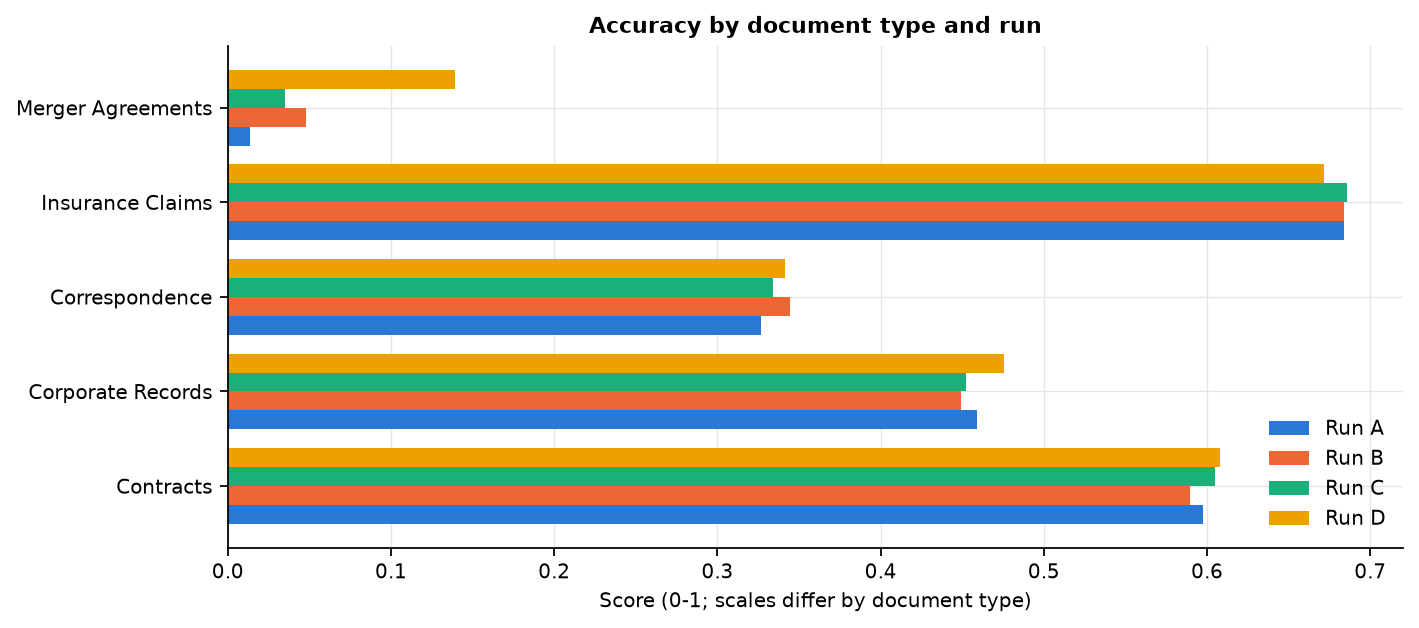

In [ ]:
pivot = df.pivot(index="doc_type", columns="run", values="score")
ax = pivot.plot.barh(figsize=(9, 4), color=[COLORS[r] for r in pivot.columns], width=0.8)
ax.set_xlabel("Score (0-1; scales differ by document type)")
ax.set_ylabel("")
ax.set_title("Accuracy by document type and run")
ax.legend(title="", loc="lower right")
plt.tight_layout()

## Merger agreements: what changed

Merger agreements are long: the median agreement in the sample runs to hundreds of thousands of characters, while the standard settings read only the first and last 30,000 characters combined. In Run D we changed the settings for this document type only, on the same 50 agreements as Run C:

| Setting | Standard (Runs A–C) | Improved (Run D) |
| --- | --- | --- |
| What the model reads | Start and end of the agreement; the middle is skipped | The whole agreement, in overlapping sections of about 47,000 characters, with answers combined |
| Instructions | General extraction instructions | Instructions written around the MAUD question set |
| Output length limit | 8,192 tokens | 6,144 tokens, with one retry if an answer is cut off |
| Sampling | temperature 0.7, other sampling at vLLM defaults | temperature 0.7, top_p 0.8, top_k 20, presence_penalty 1.0 |
| Question accuracy | 3.5% | 14.0% |
| Questions answered | 23% | 69% |
| Agreements returning a result | 46 of 50 | 50 of 50 |
| Cost per agreement | $0.0033 | $0.0147 |
| Median time per agreement | 92 s | 1,044 s |

On the 46 agreements scored under both settings, 35 improved and 1 got worse (average change +0.106 on the 0–1 scale). Several settings changed together, so this run does not show which change drove the gain.

## Total cost

GPU cost counts only the time the GPUs spent on documents. Session cost is the provider's metered charge for the whole session, including start-up, waiting between runs and shut-down.

| Runs | Documents | GPU cost on documents | Session cost | Share of session spent on documents | Session cost per document | Billed |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Runs A and C | 350 | $0.47 | $1.09 | 44% | $0.0031 | $0.00 |
| Run B | 250 | $0.32 | $0.49 | 65% | $0.0020 | $0.00 |
| Run D | 450 | $1.01 | $1.81 | 56% | $0.0040 | $0.00 |
| **All runs** | 1,050 | $1.81 | $3.39 | 53% | $0.0032 | $0.00 |

Billed is zero because the provider's monthly free credits covered the charges. Session costs exclude short exploratory test deployments run between the main runs.

## Limitations

- **One sample per run.** Each run used one random draw of 20–100 documents per type; small differences between runs may be noise.
- **Hardware and load changed together.** Going from 1 to 2 GPUs also raised the number of documents processed at once (8 to 32), so the speed gain cannot be split between the two.
- **Some outputs vary between runs.** Contracts and merger agreements are generated with some randomness (temperature 0.7), so repeated runs give slightly different answers.
- **Strict format checks.** Most insurance-claim outputs did not pass strict data-format validation even though their extraction scores are the highest; a system that rejects malformed records would need that fixed first.
- **Public data only.** Results describe this public dataset; performance on other document collections has not been measured.

## Run name cross-reference

For readers comparing against the project's internal records:

| Run | Internal study | Internal shorthand |
| --- | --- | --- |
| Run A | SAND-37 | 1×L4 C8 n=20 |
| Run B | SAND-39 | 1×L4 C8 n=50 |
| Run C | SAND-37 | 2×L4 C32 n=50 |
| Run D | SAND-40 | 2×L4 C32 n=100 |

Shorthand key: `2×L4` = two NVIDIA L4 GPUs; `C32` = 32 documents processed at once; `n=100` = documents per type. Detailed tables and charts: `SAND-37-MASTER-APPENDIX.md` in the project repository.